# Important Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Set global font sizes

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 12,        # X and Y axis label size
    'xtick.labelsize': 12,       # X tick label size
    'ytick.labelsize': 12,       # Y tick label size
    'legend.fontsize': 12,       # Legend text size
    'figure.titlesize': 12       # Main figure title size
})

# Problem:
## Replenishment process: $\emptyset \xrightarrow{\lambda_1 = e^{\mu}} X$ and 
## Reaction process: $X \xrightarrow{\lambda_2} Y$

# - The Tau-Leap Algorithm

In [3]:
#=========================================================###=========================================================#
# The stochastic push system function
# The starting point for the Stochastic Push System
#=========================================================###=========================================================#
def tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam):
    time = np.arange(0, T + tau, tau)
    X_all = np.zeros((Num_MC, nd, len(time)))

    for r in range(Num_MC):
        X = np.zeros((nd, len(time)))
        X[:, 0] = inventories.copy()
        queue_count = 0
        queue_delay = []
        t = 0
        count = 0

#=========================================================###=========================================================#
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
#=========================================================###=========================================================#
        while count < len(time) - 1:
            X[:, count + 1] = X[:, count]

            
            lambda_j = np.array([mu, lam*X[0, count]])
            Delta_C_j = np.random.poisson(lambda_j * tau)

#============== Cap consumption based on available inventory ==================#
            for j in range(J):
                for i in range(nd):
                    if C_j_c[i, j] < 0:
                        max_possible = int(X[i, count + 1] / abs(C_j_c[i, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])

# The delayed production algorithm Starts here
#=========================================================###=========================================================#
            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        
                        Q_nq_d -= Delta_P_j
                        elapsed = t + tau - t_nq_s
                        # old_t_nq_s = t_nq_s
                        t_nq_s = t + tau
                        t_span = max(0, t_span - elapsed)
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec
                        
            t += tau
            count += 1
            
# The delayed production algorithm ends here
#=========================================================###=========================================================#
#  Final state at time T for this path
#=========================================================###=========================================================#
        X_all[r] = X
    return X_all, time


# ============================================================
# Monte Carlo statistics (your original functions)
# ============================================================
def terminal_Y_statistics(X_all, Y_index=1):
    Y_N = X_all[:, Y_index, -1]
    E_Y_N = np.mean(Y_N)
    return Y_N, E_Y_N


def running_X_statistics(X_all, X_index=0):
    X_n = X_all
    E_X_n = np.mean(X_n, axis=0)
    sum_X_n = np.sum(X_n[:, X_index, :-1],axis=1)
    E_sum_X_n = np.mean(sum_X_n)

    return X_n, E_X_n, sum_X_n, E_sum_X_n


# ==================================================================================
# Exact solutions for X_n: E(X_n) = mu/lam + (x0 - (mu/lam))*a**n
 # where   a = 1 - lam * tau 
# ==================================================================================
def exact_Ex(n, x0, mu, lam, tau):
    a = 1 - lam * tau
    return (mu/lam) + a**n*(x0 - (mu/lam))

# ==================================================================================
# Exact solutions for Y_n E(Y_n) = y0 + n*tau*mu + (x0 - (mu/lam))*(1 - a**n)
# ==================================================================================
def exact_Ey(n, x0, y0, mu, lam, tau):
    a = 1 - lam * tau 
    return y0 + n*tau*mu + (x0 - (mu/lam))*(1 - a**n)
    

# - Print out 

In [4]:
# ============================================================
# Parameters
# ============================================================
nd = 2
J = 2

Num_MC = 1000                           # Monte Carlo runs
Y_demand = 30                          # Customer demand
B = 5000                               # Number of bootstrap samples 
T = 1.0                                # final time
tau = 0.02
N = T/tau

mu = 2.0
lam = 1.0
x0 = 10
y0 = 0

inventories = np.array([x0, y0])

# No delay
pT = np.array([[0, 0],
              [0, 0]])

# Consumption matrix
C_j_c = np.array([[0, -1],
                  [0,  0]])

# Production matrix
C_j_p = np.array([[1, 0],
                 [0, 1]])

# ============================================================
# Run simulation
# ============================================================
X_all, time = tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam)


# -------------------------------
# Monte Carlo estimates
# -------------------------------
_, E_X_n, _, _ = running_X_statistics(X_all)
_, E_Y_N_mc = terminal_Y_statistics(X_all)

# -------------------------------
# Exact values
# -------------------------------
Ex_exact = np.array([exact_Ex(n, x0, mu, lam, tau) for n in range(len(time))])
Ey_exact = np.array([exact_Ey(n, x0, y0, mu, lam, tau) for n in range(len(time))])


# - Plot comparison for the MC and the exact solution for $\mathbb{E}\left(\overline{X}^\tau_n(\mu)\right)$ 

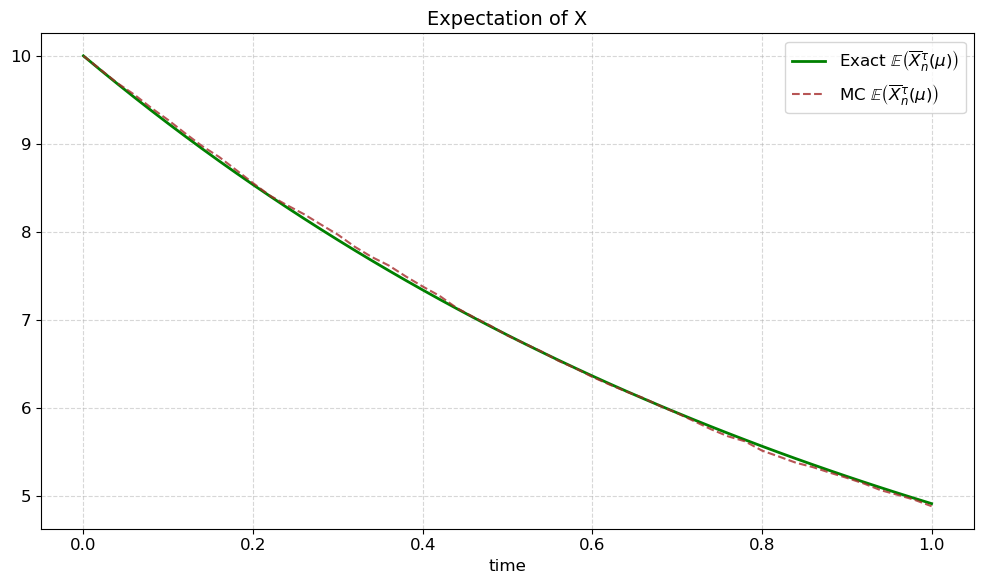

In [5]:
# -------------------------------
# Plot comparison for the MC for X_n and the exact for X_n
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(time, Ex_exact, color='green', label=r"Exact $\mathbb{E}\left(\overline{X}^\tau_n(\mu)\right)$", linewidth=2)
plt.plot(time, E_X_n[0], '--', color='brown', label=r"MC $\mathbb{E}\left(\overline{X}^\tau_n(\mu)\right)$", alpha=0.8)
plt.xlabel("time")
plt.title(r"Expectation of X")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Plot comparison for the MC and the exact solution for $\mathbb{E}\left(\overline{Y}^\tau_N(\mu)\right)$ 

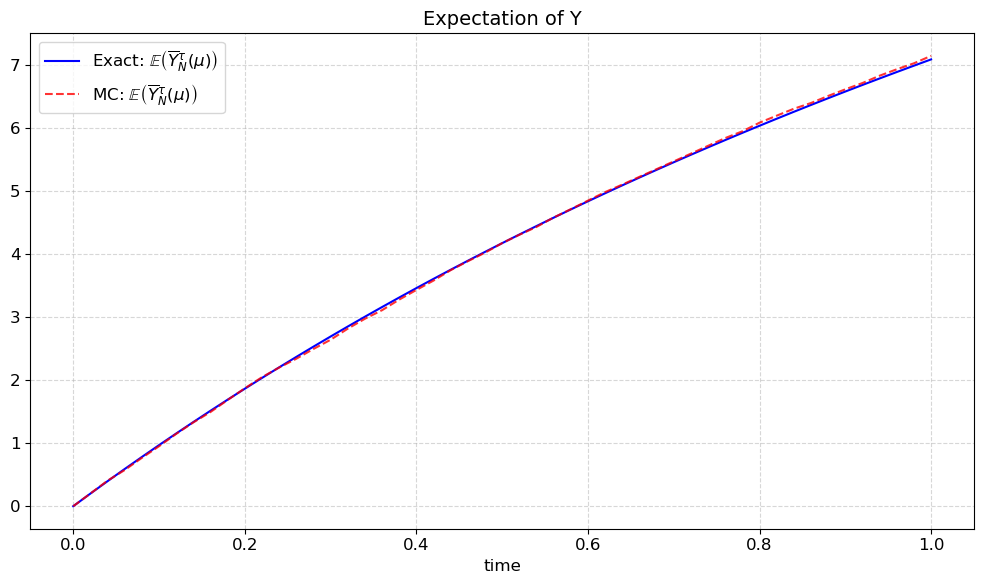

In [6]:
# -------------------------------
# Plot comparison for the MC for Y_n and the exact for Y_n
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(time, Ey_exact, color='blue', label=r"Exact: $\mathbb{E}\left(\overline{Y}^\tau_N(\mu)\right)$", alpha=1)
plt.plot(time, E_X_n[1], '--', color='red', label=r"MC: $\mathbb{E}\left(\overline{Y}^\tau_N(\mu)\right)$", alpha=0.8)
plt.xlabel("time")
plt.title("Expectation of Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - To know the optimal $\mu$ for $\mathbb{E}\left(\overline{Y}_N^\tau(\mu)\right) = M_N^\tau$ using $\tau$-leap Algorithm

# - Bootstrap with Linear fit

In [7]:
def bootstrap_Lin_fit(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand):
    Y_N_mu = {}
    EY_N_values = {}

    # ==================== Precompute E(Y(T) for each mu ====================
    for mu in mu_values:
        X_all, _ = tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam)
        Y_N, _ = terminal_Y_statistics(X_all)
        Y_N_mu[mu] = Y_N
        EY_N_values[mu] = np.mean(Y_N)

    # ==================== store raw EY curve ====================
    EY_array = np.array([EY_N_values[mu] for mu in mu_values])

    # ==================== Bootstrap ====================
    mu_star_samples = np.zeros(B)
    Y_fit = np.zeros((B, len(mu_values)))
    n = Num_MC

    for b in range(B):

        EY_boot = []

        # =============== compute EY for each mu using bootstrap ================
        for mu in mu_values:
            samples = np.random.choice(Y_N_mu[mu], size=n, replace=True)
            EY_boot.append(np.mean(samples))

        EY_boot = np.array(EY_boot)

        # ==================== Linear regression ====================
        a1, a0 = np.polyfit(mu_values, EY_boot, 1)

        # ==================== store results (Y_fit = a1*mu + a0) ====================
        Y_fit[b, :]  = a1*mu_values + a0


        # ==================== Solve for mu* ====================
        if a1 != 0:
            mu_star = (Y_demand - a0)/a1
            mu_star_samples[b] = mu_star 

    return Y_fit, EY_array, np.array(mu_star_samples)

# - Exact optimal mu
def exact_optimal_mu(x0, y0, N, tau, lam, Y_demand):
    A = N*tau - (1-(1-lam*tau)**N)/lam
    B = y0 + x0*(1-(1-lam*tau)**N) - Y_demand

    # exact optimal mu
    mu_star = -B/A
    return mu_star

# - Print out for linear fit

In [8]:
# # ============================================================
# # Parameters
# # ============================================================
mu_values = np.linspace(50, 70, 60)          

mu_star = exact_optimal_mu(x0, y0, N, tau, lam, Y_demand)
Y_fit, EY_values, mu_star_samples = bootstrap_Lin_fit(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand)

# - Plot

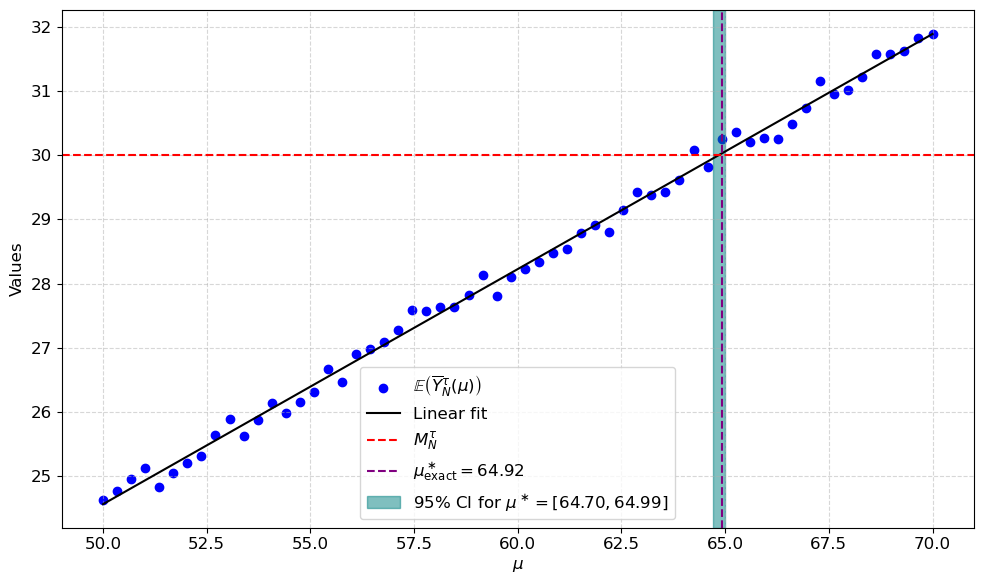

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(mu_values, EY_values, color='blue', label=r"$\mathbb{E}\left(\overline{Y}_N^\tau(\mu)\right)$")
plt.plot(mu_values, Y_fit.mean(axis=0), color='black', label="Linear fit")
plt.axhline(Y_demand, color='red', linestyle='--', label=r'$M_N^\tau$')

plt.axvline(mu_star, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star:.2f}$')


CI = np.quantile(mu_star_samples, [0.025, 0.975])                                              # 95% CI
plt.axvspan(CI[0], CI[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI[0]:.2f}, {CI[1]:.2f}]$')

plt.xlabel(r"$\mu$")
plt.ylabel(r"Values")
# plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

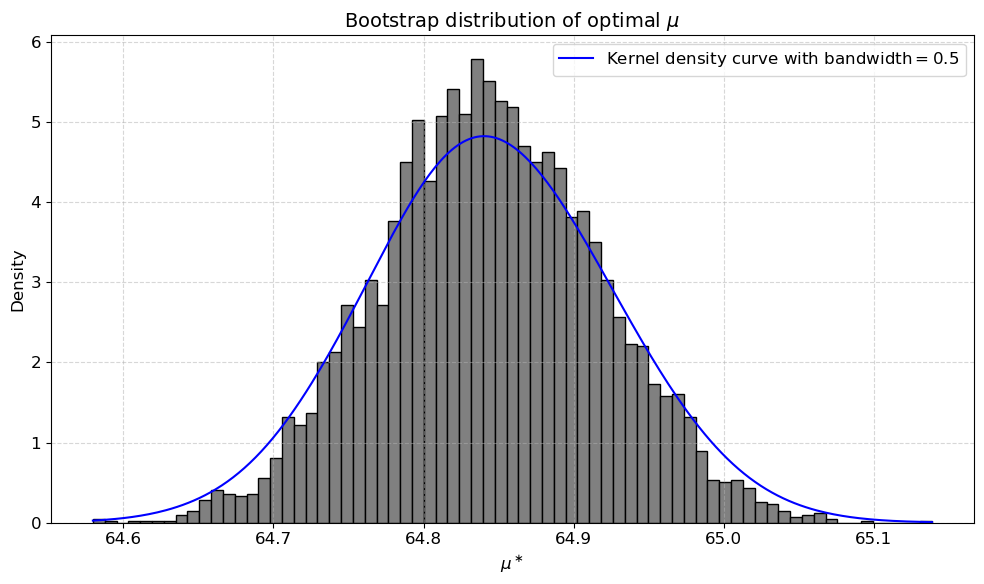

In [10]:
n = len(mu_star_samples)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples, bins=bins, density=True, color ='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples, bw_method=0.5)
x = np.linspace(min(mu_star_samples), max(mu_star_samples), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for $\mathbb{E}\left(\overline{Y}_N^\tau(\mu)\right) = M_N^\tau$ and Distribution of the optimal mu

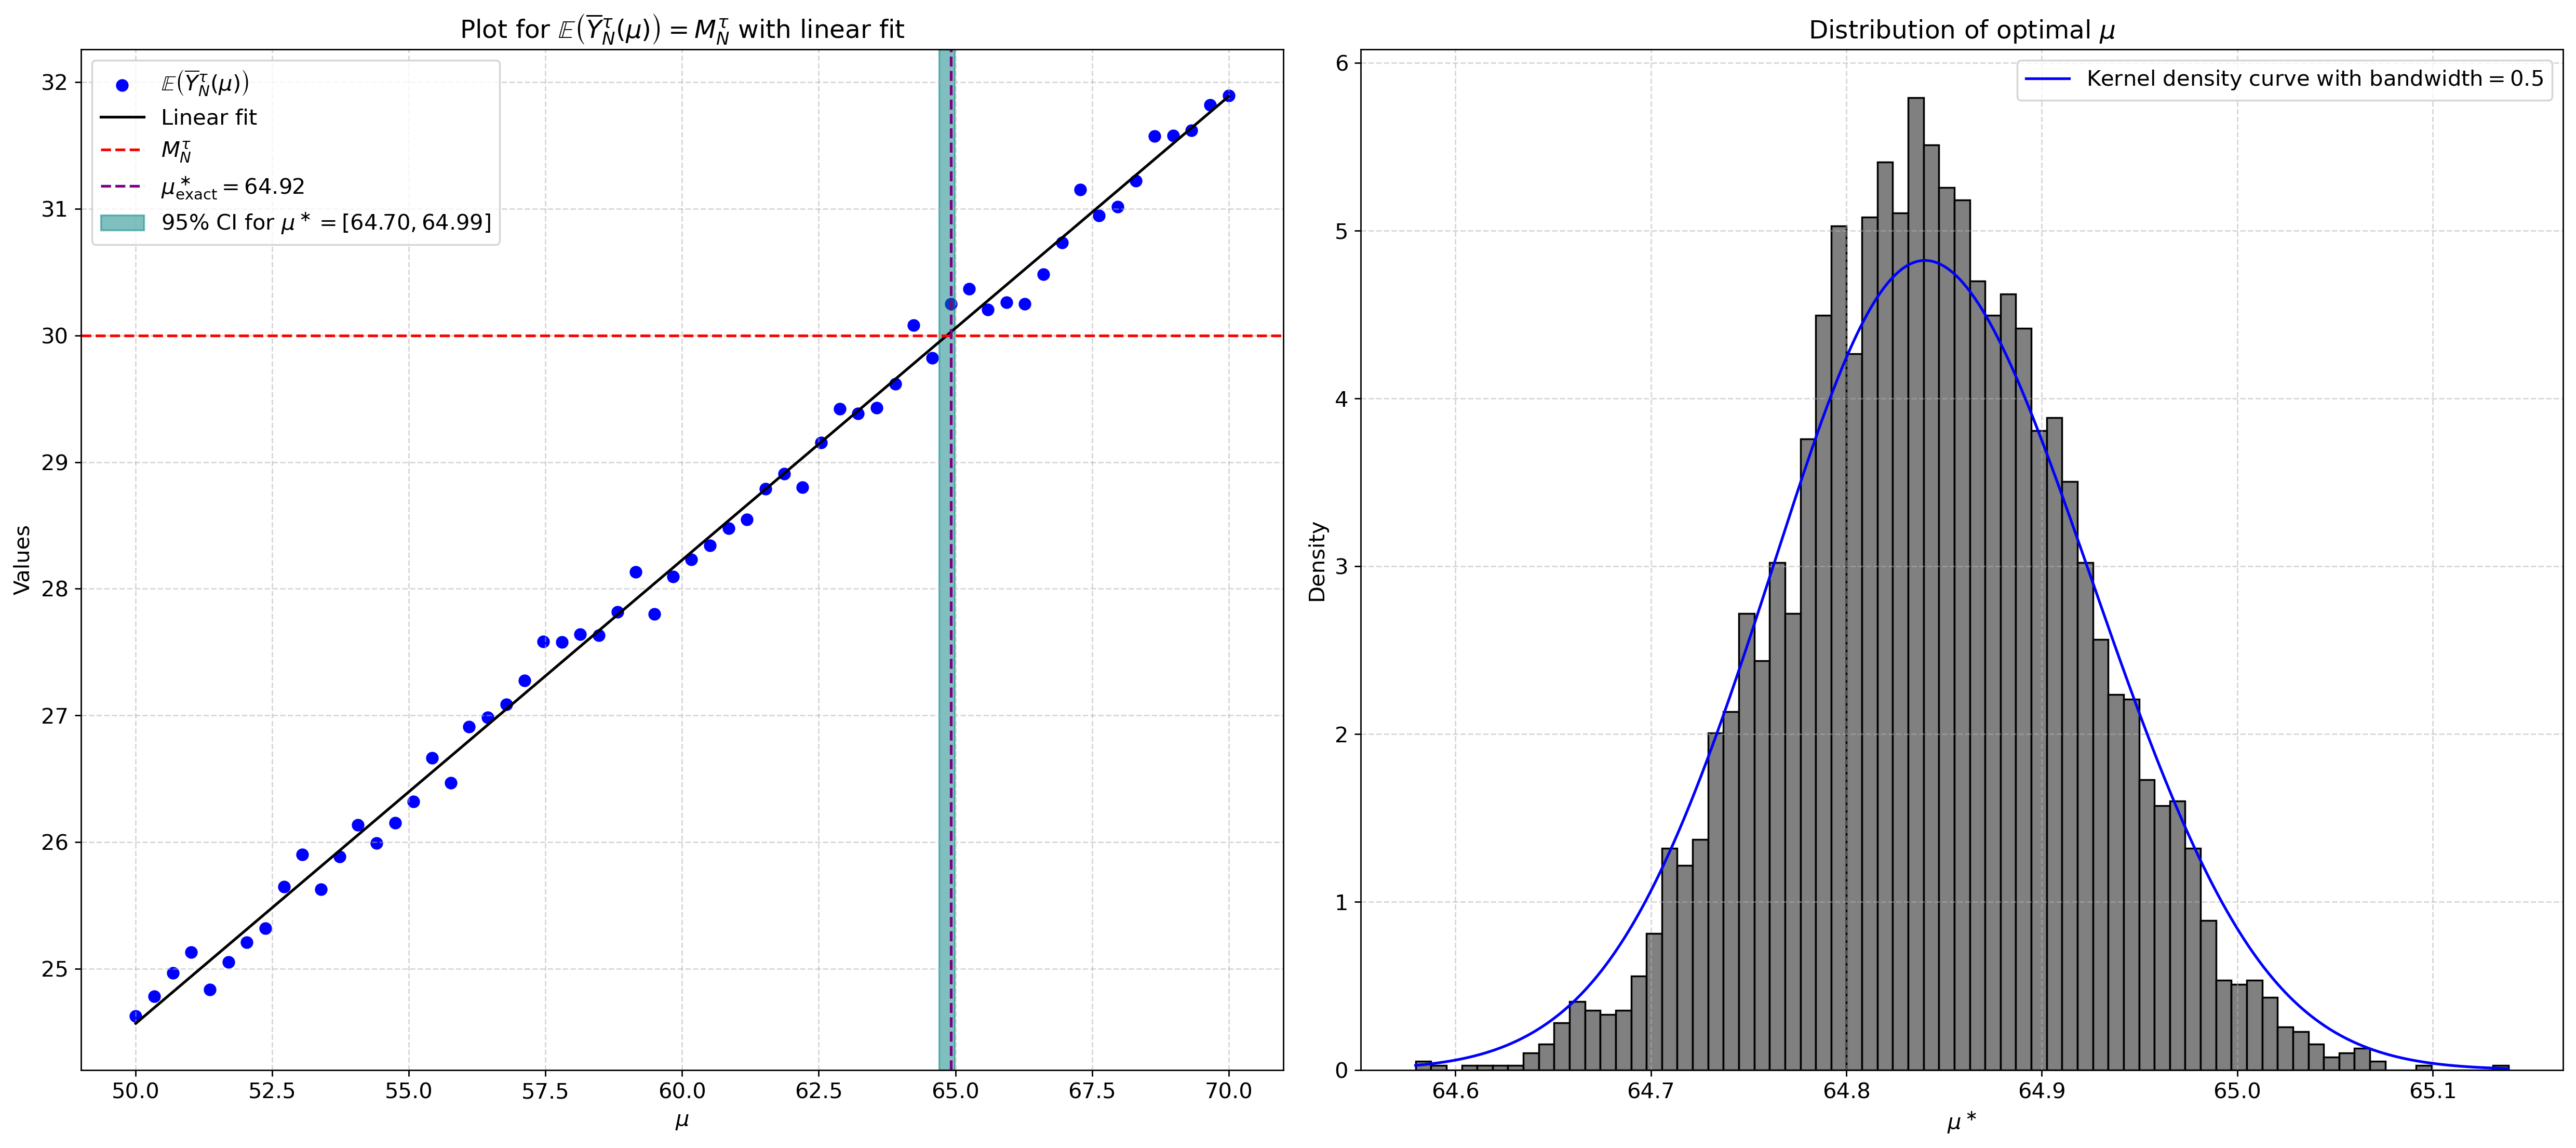

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Linear Regression Fit
# ============================================================
ax = axes[0]
ax.scatter(mu_values, EY_values, color='blue', label=r"$\mathbb{E}\left(\overline{Y}_N^\tau(\mu)\right)$")
ax.plot(mu_values, Y_fit.mean(axis=0), color='black', label="Linear fit")
ax.axhline(Y_demand, color='red', linestyle='--', label=r'$M_N^\tau$')

ax.axvline(mu_star, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star:.2f}$')

CI = np.quantile(mu_star_samples, [0.025, 0.975])                                              # 95% CI
ax.axvspan(CI[0], CI[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI[0]:.2f}, {CI[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title(r"Plot for $\mathbb{E}\left(\overline{Y}_N^\tau(\mu)\right) = M_N^\tau$ with linear fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]
n = len(mu_star_samples)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples, bins=bins, density=True, color ='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples, bw_method=0.5)
x = np.linspace(min(mu_star_samples), max(mu_star_samples), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(r"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)


# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu1_Tau_leap.png", format='png', bbox_inches='tight')
plt.show()

# - To know the optimal $\mu$
## Objective function: $\min_{\mu \ge 0} J(\mu) = \frac{\kappa}{2}\left[\mathbb{E}(\overline{Y}_N^\tau(\mu))- M_{\rm{N}}^\tau\right]^2 + \alpha \mu$ using Tau-leap Algorithm

# - Bootstrap with Quadratic fit

In [12]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap_quadratic_fit1(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand, kappa, alpha):
    Y_N_mu1 = {}
    
    for mu in mu_values:
        X_all, _ = tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam)
        Y_N, _ = terminal_Y_statistics(X_all)
        Y_N_mu1[mu] = Y_N

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples1 = np.zeros(B)
    Y_Q_fit1 = np.zeros((B, len(mu_values)))
    n = Num_MC
    
    for b in range(B):
        J_mu_boot1 = []
        
        for mu in mu_values:
            samples1 = np.random.choice(Y_N_mu1[mu], size=n, replace=True)
            EY_N_value1 = np.mean(samples1)
            J_mu1 = 0.5*kappa*(EY_N_value1 - Y_demand)**2 + alpha * mu
            J_mu_boot1.append(J_mu1)
            
        J_mu_boot1 = np.array(J_mu_boot1)

        # ---------- Quadratic fit ----------
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot1, 2)

        # store results a_0 + a_1*mu + a_2*mu^2
        Y_Q_fit1[b, :]  = a2*mu_values**2 + a1*mu_values + a0  
        
        # ============================================================
        # Optimal mu
        # ============================================================    
        mu_star_samples1[b] = - a1/(2*a2)
                
    return Y_Q_fit1, J_mu_boot1, np.array(mu_star_samples1)

# - Exact optimal mu
def exact_optimal_mu1(x0, y0, N, tau, lam, kappa, alpha, Y_demand):
    A = N*tau - (1-(1-lam*tau)**N)/lam
    B = y0 + x0*(1-(1-lam*tau)**N) - Y_demand

    # exact optimal mu
    mu_star1 = -(B +(alpha/(A*kappa)))/A
    return mu_star1


# - Print Out

In [13]:
# # ============================================================
# # Parameters
# # ============================================================
alpha = 0.5                     # control penalty
kappa = 1                         # unit penalty for deviating from costumer demand
mu_values = np.linspace(20, 70, 60)

mu_star1 = exact_optimal_mu1(x0, y0, N, tau, lam, kappa, alpha, Y_demand)
Y_Q_fit1, J_mu_boot1, mu_star_samples1 = bootstrap_quadratic_fit1(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand, kappa, alpha)


# - Plot

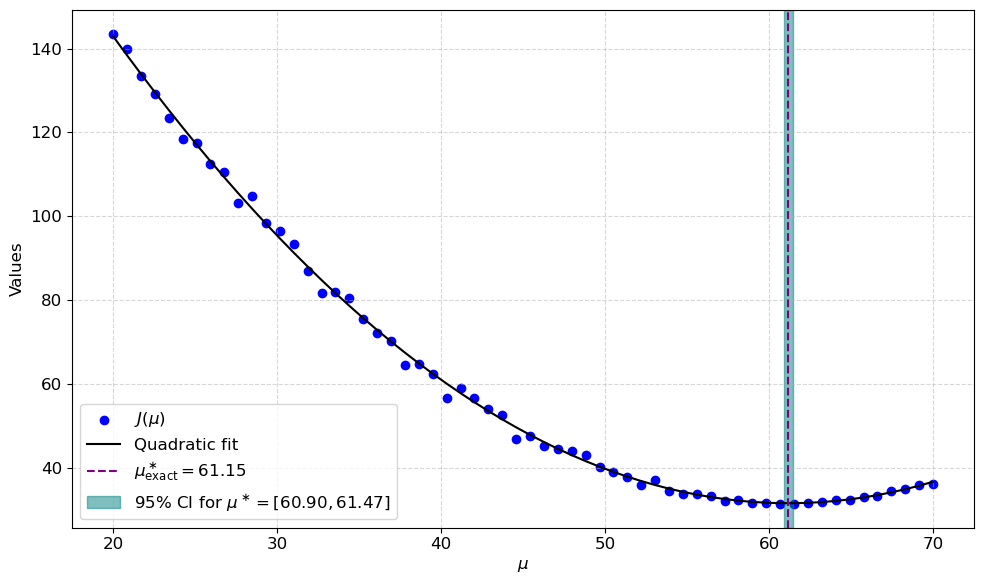

In [14]:
# ============================================================
# Plot mu vs J(mu) and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot1, color='blue', label=r"$J(\mu)$")
plt.plot(mu_values, Y_Q_fit1.mean(axis=0), color ='black', label=r'Quadratic fit')
plt.axvline(mu_star1, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star1:.2f}$')

CI1 = np.quantile(mu_star_samples1, [0.025, 0.975])        # 95% CI
plt.axvspan(CI1[0], CI1[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI1[0]:.2f}, {CI1[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
# plt.title(r'')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

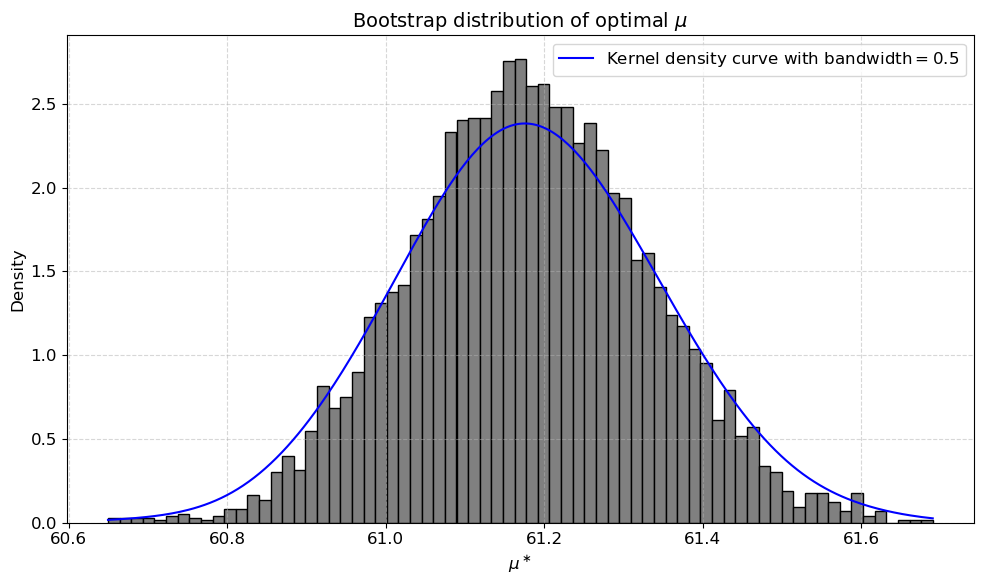

In [15]:
n = len(mu_star_samples1)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples1, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples1, bw_method=0.5)
x = np.linspace(min(mu_star_samples1), max(mu_star_samples1), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label=r"Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for the cost function with quadratic fit and Distribution of the optimal mu

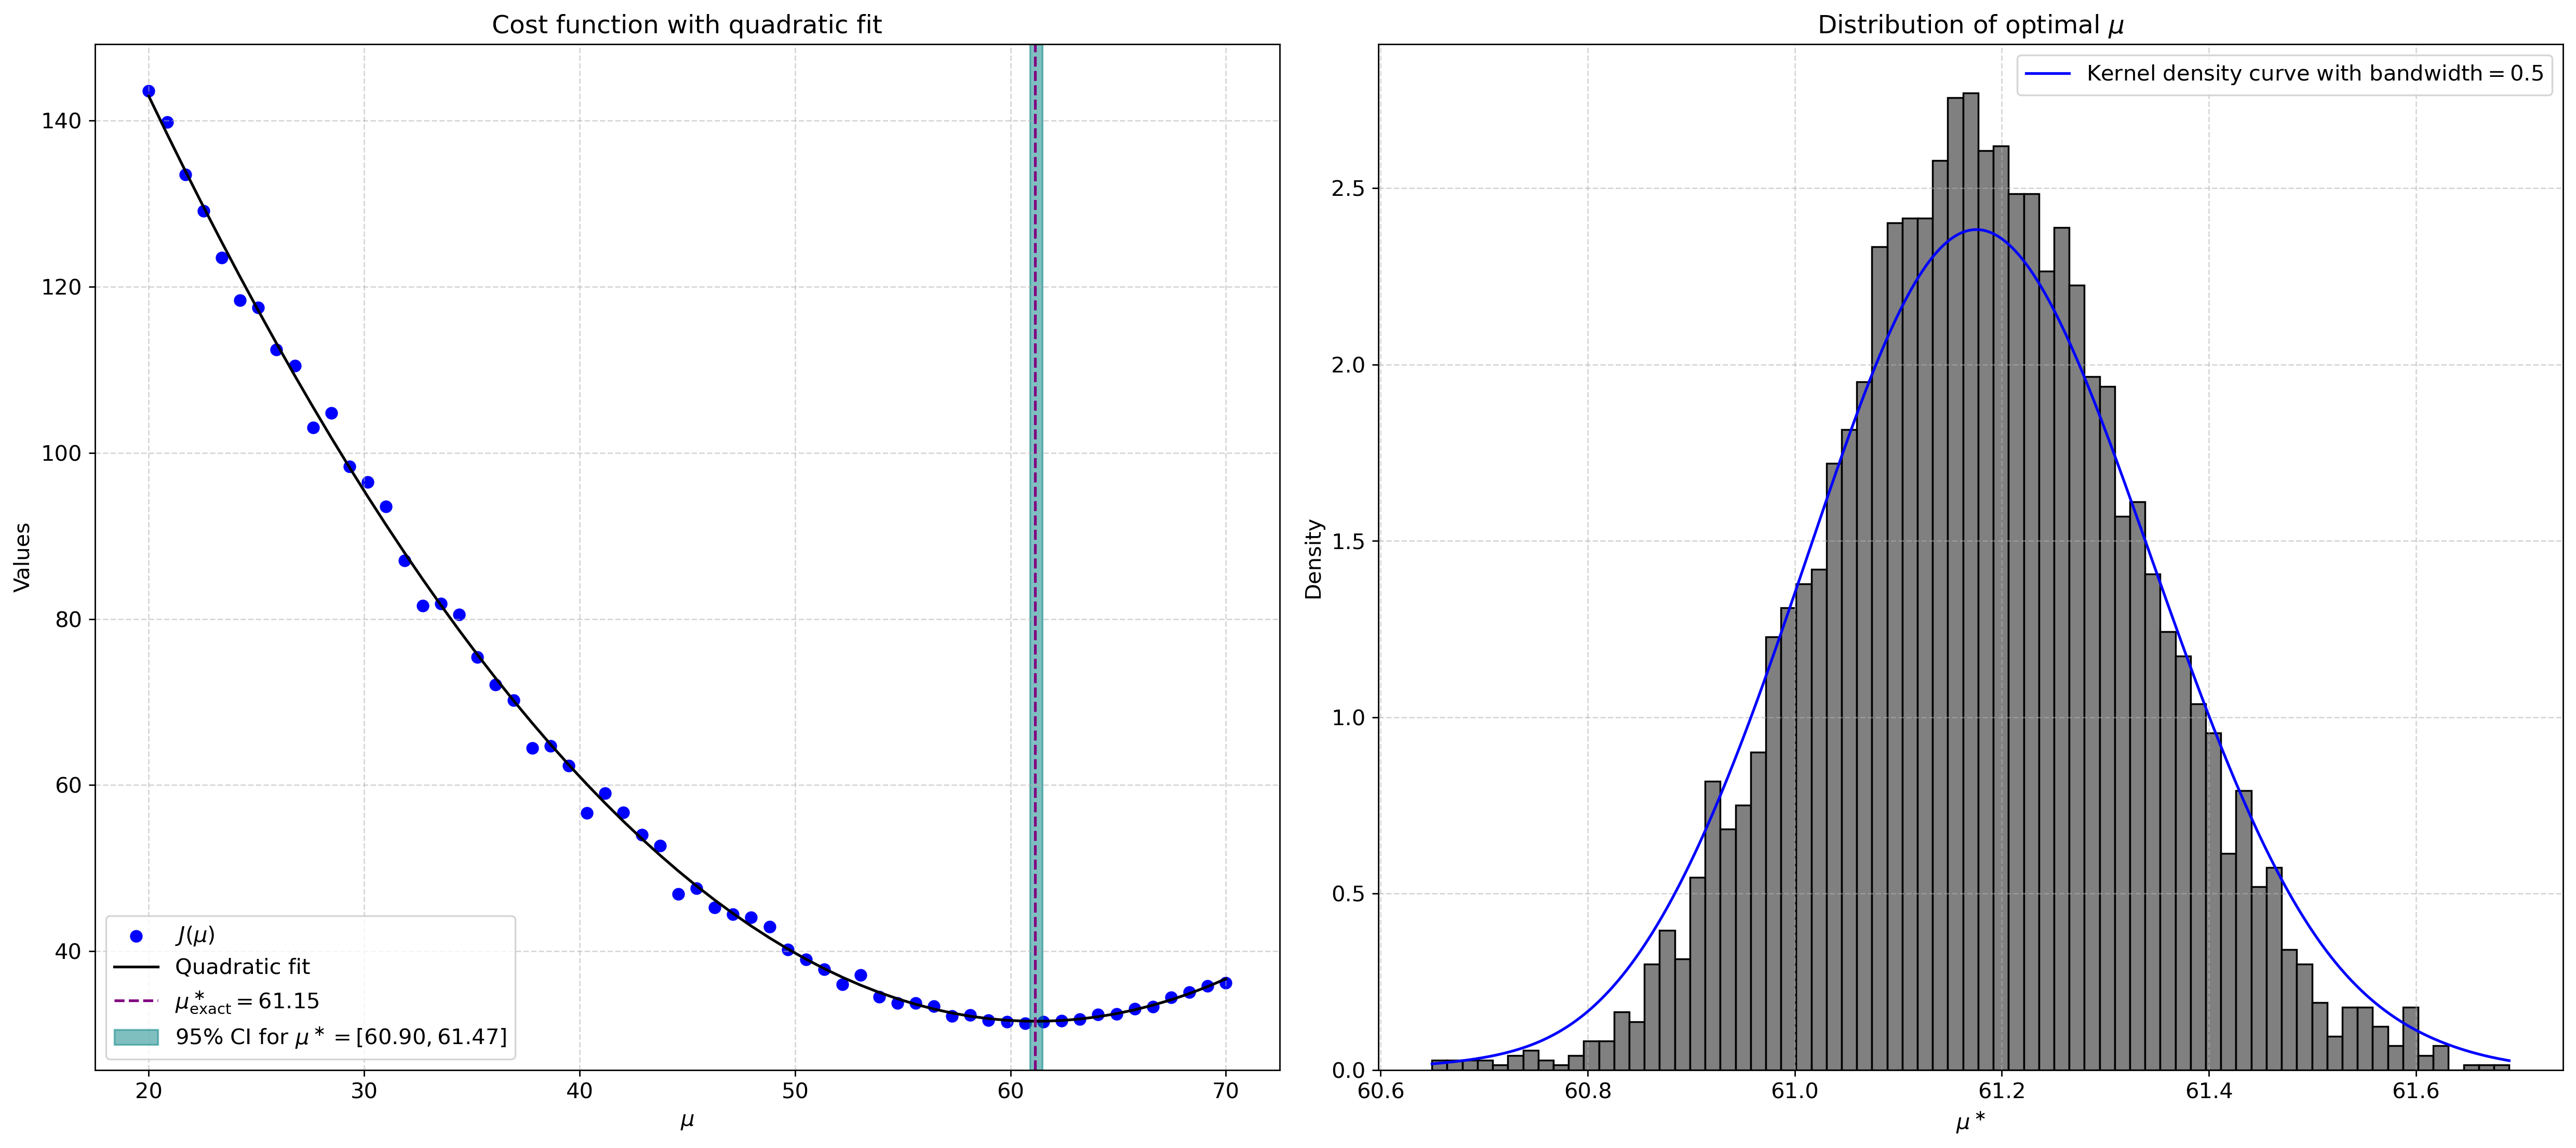

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]
ax.scatter(mu_values, J_mu_boot1, color='blue', label=r"$J(\mu)$")
ax.plot(mu_values, Y_Q_fit1.mean(axis=0), color ='black', label=r'Quadratic fit')
ax.axvline(mu_star1, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star1:.2f}$')

CI1 = np.quantile(mu_star_samples1, [0.025, 0.975])        # 95% CI
ax.axvspan(CI1[0], CI1[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI1[0]:.2f}, {CI1[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title("Cost function with quadratic fit")

# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]
n = len(mu_star_samples1)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples1, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples1, bw_method=0.5)
x = np.linspace(min(mu_star_samples1), max(mu_star_samples1), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(r"Distribution of optimal $\mu$")

# ax.title(r"Bootstrap distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu2_Tau_leap.png", format='png', bbox_inches='tight')
plt.show()


# - To find the optimal $\mu$ at $95\%$ 

## Objective function:  $\min_{\mu \ge 0} J(\mu) = h \tau \sum_{n=0}^{N-1}\mathbb{E}[\overline{X}_n] + \frac{\kappa}{2}\left[\mathbb{E}(\overline{Y}_N)- \overline{Y}_{\rm{Demand}}\right]^2 + \alpha \mu$ using Tau-leap Algorithm 

## Note: $\mathbb{E}\left[\int_{0}^{T}\overline{X}(t)dt\right] \approx \mathbb{E}\left[\sum_{n=0}^{N-1}\overline{X}_n(t_{n+1}-t_n)\right] \approx \tau \sum_{n=0}^{N-1}\mathbb{E}[\overline{X}_n]$ in discrete-time version

# - Bootstrap with quadratic fit

In [17]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap_quadratic_fit2(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand, h, kappa, alpha):
    Y_N_mu2 = {}                      # Store rdv of Y(T) to resmaple from later
    SumX_n2 = {}                      # Store rdv of int X(t) dt to resmaple from later
    
    for mu in mu_values:
        X_all, _ = tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam)
        _, _, sum_X_n, _ = running_X_statistics(X_all)
        SumX_n2[mu] = sum_X_n
        Y_N2, _ = terminal_Y_statistics(X_all)
        Y_N_mu2[mu] = Y_N2

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples2 = np.zeros(B)
    Y_Q_fit2 = np.zeros((B, len(mu_values)))
    n = Num_MC
    
    for b in range(B):
        J_mu_boot2 = []
        
        for mu in mu_values:
            X_n2 = np.random.choice(SumX_n2[mu], size=n, replace=True)
            Y_N2 = np.random.choice(Y_N_mu2[mu], size=n, replace=True)
            
            EX2 = np.mean(X_n2)
            EY_N2 = np.mean(Y_N2)
            
            J_mu2 = h*tau*EX2 +(kappa/2)* (EY_N2 - Y_demand)**2 + alpha*mu
            J_mu_boot2.append(J_mu2)

        J_mu_boot2 = np.array(J_mu_boot2)
        
        # =========== Quadratic fit ===========
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot2, 2)

        # =========== store results a_0 + a_1*mu + a_2*mu^2 ===========
        Y_Q_fit2[b, :]  = a0 + a1*mu_values + a2*mu_values**2
        
        # ============================================================
        # Optimal mu
        # ============================================================    
        mu_star_samples2[b] = - a1/(2*a2)
                
    return Y_Q_fit2, J_mu_boot2, np.array(mu_star_samples2)


# - Exact optimal mu
def exact_optimal_mu2(x0, y0, N, tau, lam, h, kappa, alpha, Y_demand):
    A = N*tau - (1-(1-lam*tau)**N)/lam
    B = y0 + x0*(1-(1-lam*tau)**N) - Y_demand

    # exact optimal mu
    mu_star2 = -(B + ((A*h/lam)+alpha)/(A*kappa))/A
    return mu_star2

# - Print out

In [18]:
# # ============================================================
# # Parameters
# # ============================================================
alpha = 0.5                            # control penalty
h, kappa = 0.5 , 0.5                   # holding cost/unit, unit penalty for deviating from costumer demand
mu_values = np.linspace(20, 70, 60)

mu_star2 = exact_optimal_mu2(x0, y0, N, tau, lam, h, kappa, alpha, Y_demand)
Y_Q_fit2, J_mu_boot2, mu_star_samples2 = bootstrap_quadratic_fit2(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand, h, kappa, alpha)

# - Plot

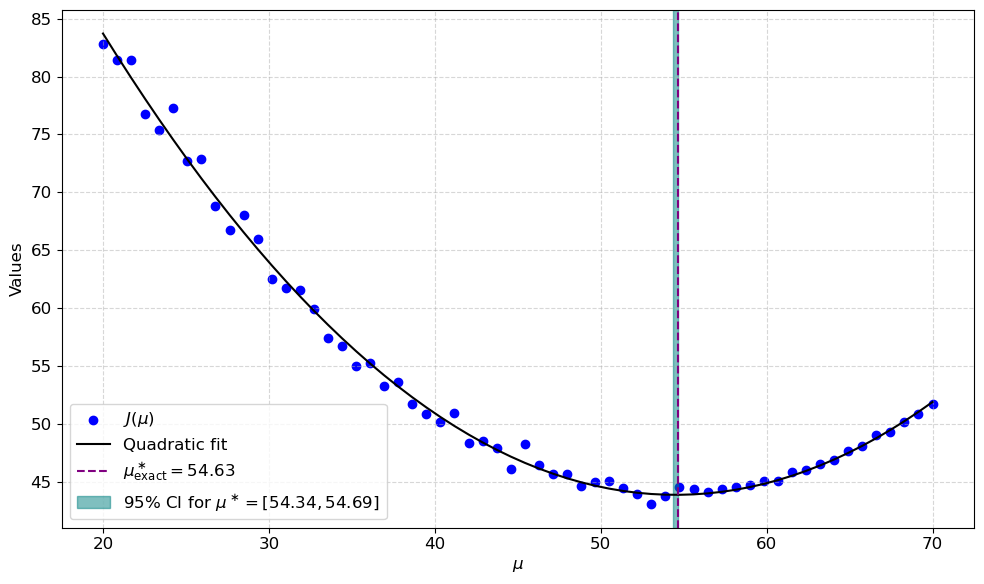

In [19]:
# ============================================================
# Plot mu vs J(mu) and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot2, color='blue', label=r"$J(\mu)$")

plt.plot(mu_values, Y_Q_fit2.mean(axis=0), color ='black', label=r'Quadratic fit')
plt.axvline(mu_star2, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star2:.2f}$')


CI2 = np.quantile(mu_star_samples2, [0.025, 0.975])        # 95% CI
plt.axvspan(CI2[0], CI2[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI2[0]:.2f}, {CI2[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

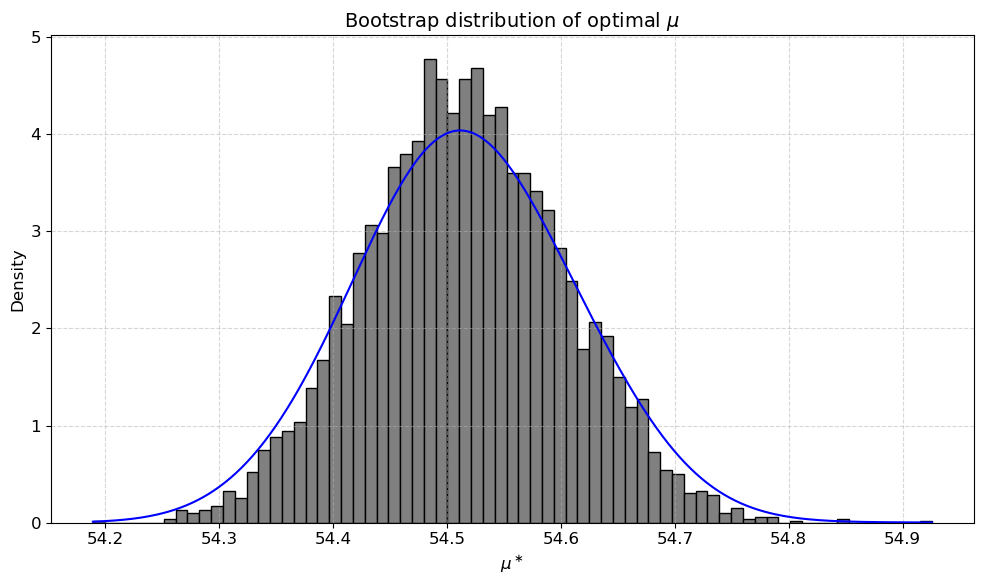

In [20]:
n = len(mu_star_samples2)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples2, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples2, bw_method=0.5)
x = np.linspace(min(mu_star_samples2), max(mu_star_samples2), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for the cost function with quadratic fit and Distribution of the optimal mu

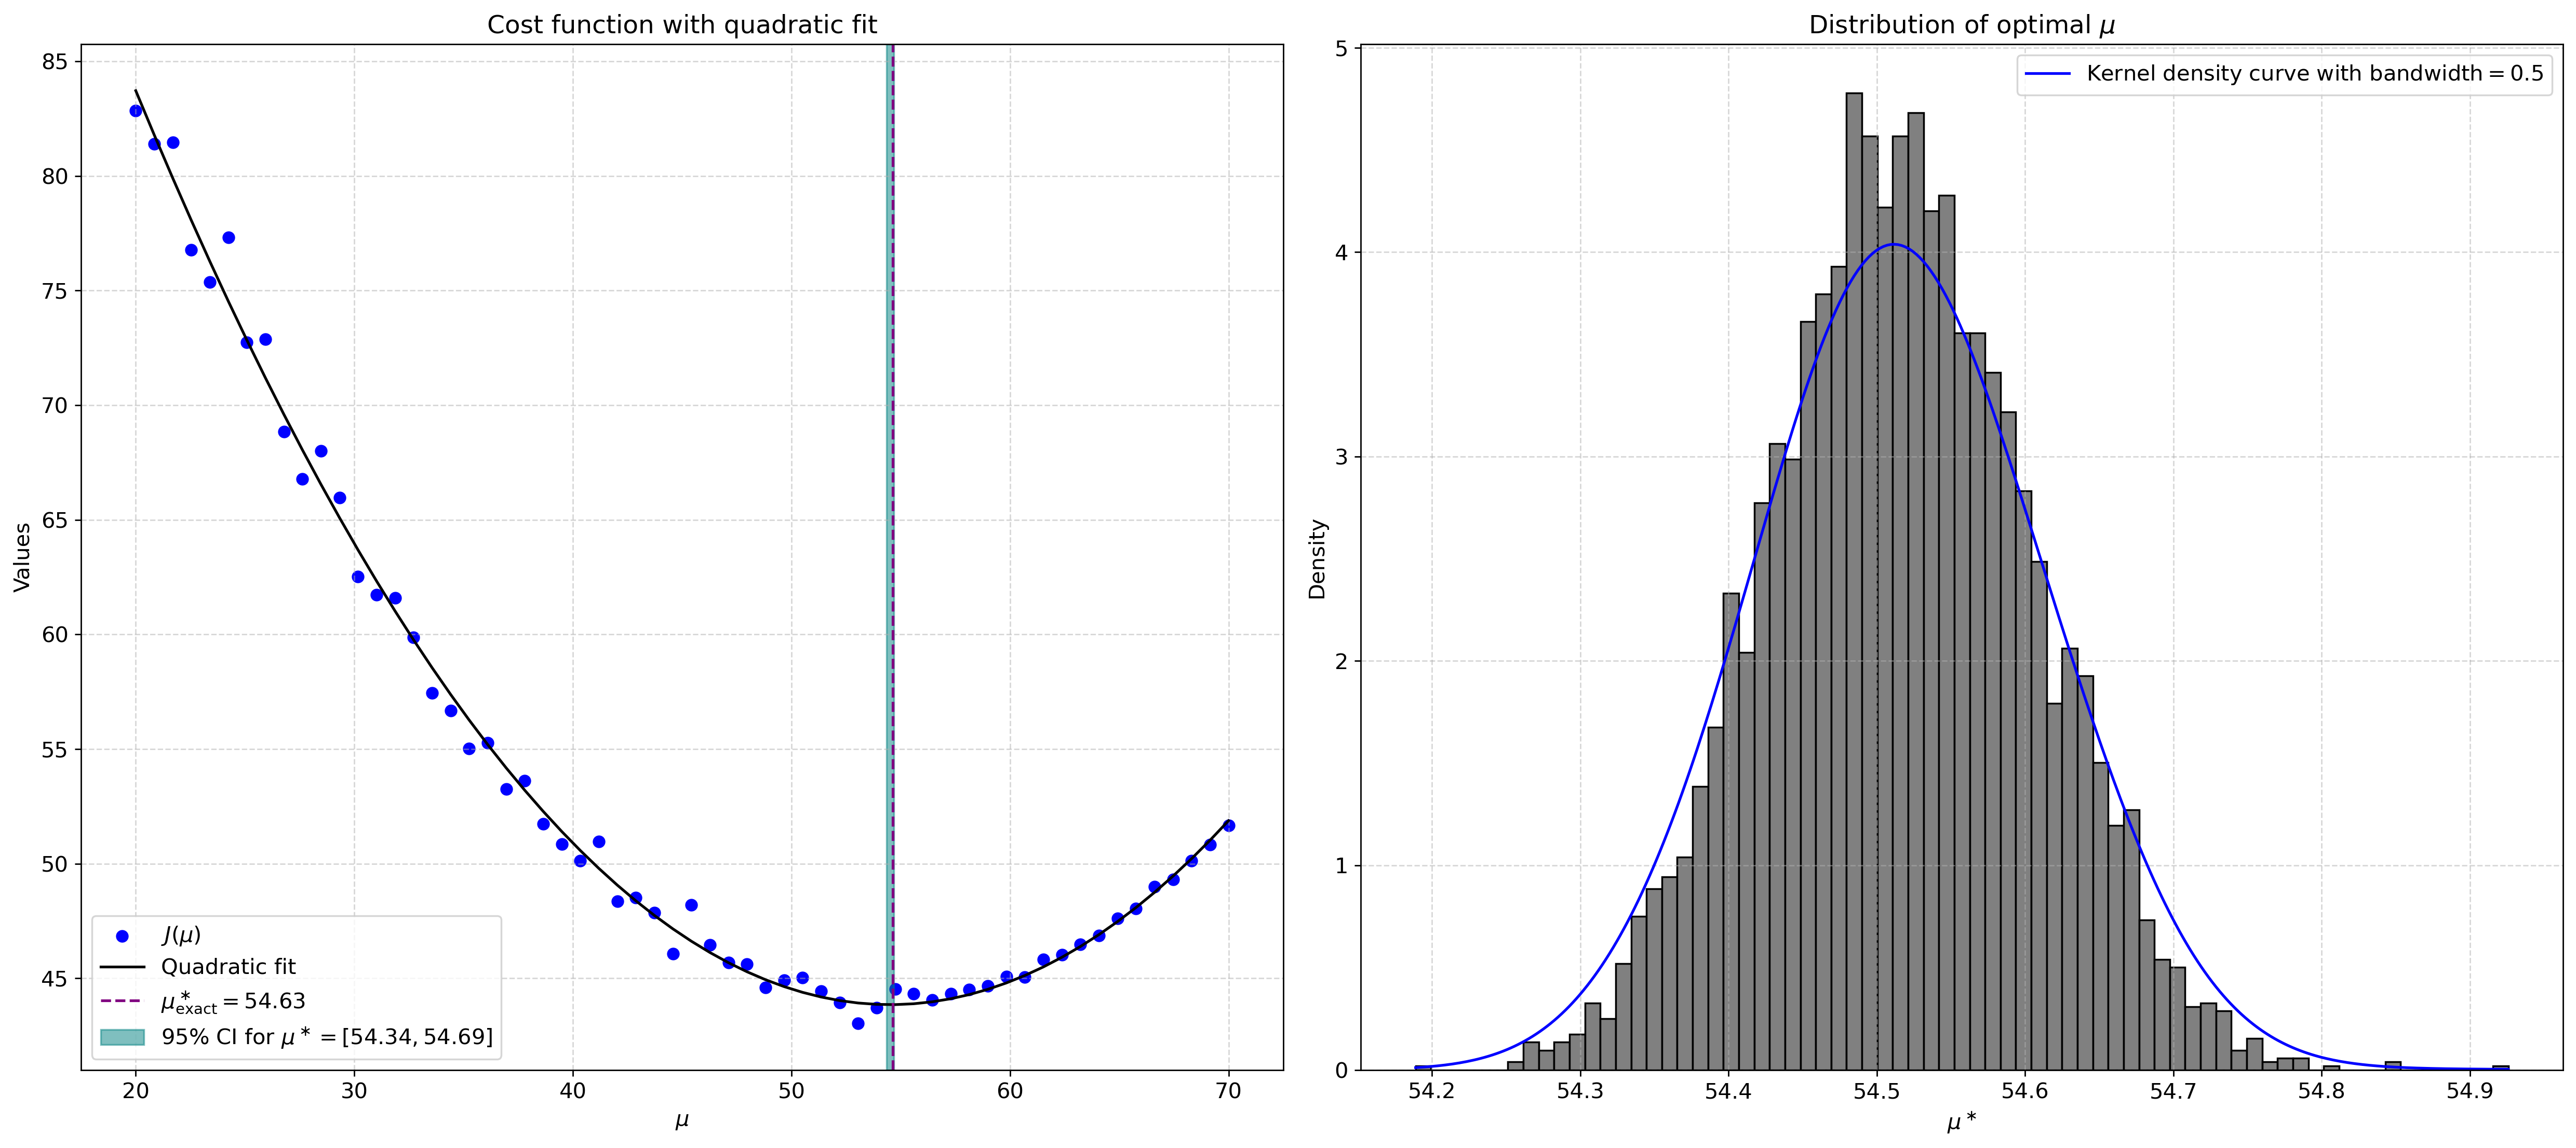

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, J_mu_boot2, color='blue', label=r"$J(\mu)$")

ax.plot(mu_values, Y_Q_fit2.mean(axis=0), color ='black', label=r'Quadratic fit')
ax.axvline(mu_star2, color='purple', linestyle='--', label=fr'$\mu_{{\rm exact}}^\ast = {mu_star2:.2f}$')

CI2 = np.quantile(mu_star_samples2, [0.025, 0.975])        # 95% CI
ax.axvspan(CI2[0], CI2[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI2[0]:.2f}, {CI2[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title("Cost function with quadratic fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples2)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples2, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples2, bw_method=0.5)
x = np.linspace(min(mu_star_samples2), max(mu_star_samples2), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(fr"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu3_Tau_leap.png", format='png', bbox_inches='tight')
plt.show()


# - To find the optimal $\mu$
## Objective function: $\min_{\mu \ge 0} J(\mu) = h \tau \sum_{n=0}^{N-1}\mathbb{E}[\overline{X}_n^\tau(\mu)] + \frac{\kappa}{2}\left[\mathbb{E}(\overline{Y}_N^\tau(\mu))- M_{\rm{N}}^\tau\right]^2 + \alpha \mu$ 

## Subj. to: $\mathbb{E}(\overline{Y}_N^\tau(\mu)) \ge M_{\rm{N}}^\tau$ using Tau-leap Algorithm

# - Bootstrap with Linear and Quadratic fit

In [22]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap_quad_lin_fit(nd, J, Num_MC, T, tau, C_j_c, inventories, mu_values, B, Y_demand, h, kappa, alpha):
    Y_N_mu3 = {}                                                 # Store rdv of Y(T) to resmaple from later
    SumX_n3 = {}                                                 # Store rdv of int X(t) dt to resmaple from later
    EY_values3 = {}                                              # Store the E(Y(T))
    
    for mu in mu_values:
        X_all, _ = tau_leap_algorithm(nd, J, Num_MC, T, tau, pT, C_j_c, C_j_p, inventories, mu, lam)
        _, _, sum_X_n3, _ = running_X_statistics(X_all)
        SumX_n3[mu] = sum_X_n3
        Y_N3, _ = terminal_Y_statistics(X_all)
        Y_N_mu3[mu] = Y_N3
        EY_values3[mu] = np.mean(Y_N3)

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples3 = np.zeros(B)
    Y_fit_linear = np.zeros((B, len(mu_values)))
    Y_fit_quadratic = np.zeros((B, len(mu_values)))
    n = Num_MC
    
    for b in range(B):
        EY_boot3 = []
        
        J_mu_boot3 = []
        
        for mu in mu_values:
            X_samples = np.random.choice(SumX_n3[mu], size=n, replace=True)           # resample from X(t) dt with replacement
            Y_samples = np.random.choice(Y_N_mu3[mu], size=n, replace=True)         # resample from Y(T) with replacement

            EX3 = np.mean(X_samples)
            EY_N3 = np.mean(Y_samples)
            EY_boot3.append(EY_N3)
                
            J_mu3 = h*EX3*tau + (kappa*0.5)*(EY_N3 - Y_demand)**2 + alpha*mu
            J_mu_boot3.append(J_mu3)

        EY_boot3 = np.array(EY_boot3)
        J_mu_boot3 = np.array(J_mu_boot3)

        
        # store results
        # ---------- Linear regression (slope3*mu_values + intercept3)----------
        slope3, intercept3 = np.polyfit(mu_values, EY_boot3, 1)
        Y_fit_linear[b, :]  = slope3*mu_values + intercept3
        
        # ---------- Quadratic fit ----------
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot3, 2)

        # store results a_0 + a_1*mu + a_2*mu^2
        Y_fit_quadratic[b, :]  = a0 + a1*mu_values + a2*mu_values**2


        # ---------- Solve for mu* ----------
        if slope3 != 0:
            mu_star = (Y_demand - intercept3) / slope3
            mu_star_samples3[b] = mu_star 

    return Y_fit_linear, Y_fit_quadratic, J_mu_boot3, EY_boot3, np.array(mu_star_samples3)


# - Exact optimal mu
def exact_optimal_mu3(x0, y0, N, tau, lam, h, kappa, alpha, Y_demand, eta1, eta2):
    A = N*tau - (1-(1-lam*tau)**N)/lam
    B = y0 + x0*(1-(1-lam*tau)**N) - Y_demand
    D = eta1 + eta2*A - alpha - h*A/lam

    # exact optimal mu
    mu_star3 = (-B + (D/(kappa*A)))/A
    return mu_star3


# - Print out

In [23]:
# ============================================================
# Parameters
# ============================================================
alpha = 0.5                            # control penalty
eta1, eta2 = 0.5, 0.5                  # Lagrange multipliers
h, kappa = 0.5 , 0.5                   # holding cost/unit, unit penalty for deviating from costumer demand
mu_values = np.linspace(20, 70, 60)

mu_star3 = exact_optimal_mu3(x0, y0, N, tau, lam, h, kappa, alpha, Y_demand, eta1, eta2)
Y_fit_lin, Y_fit_quad, J_mu_boot3, EY_boot3, mu_star_samples3 = bootstrap_quad_lin_fit(nd, J, Num_MC, T, tau, C_j_c, 
                                                                                               inventories, mu_values, B, Y_demand, h, kappa, alpha)


# - Plot

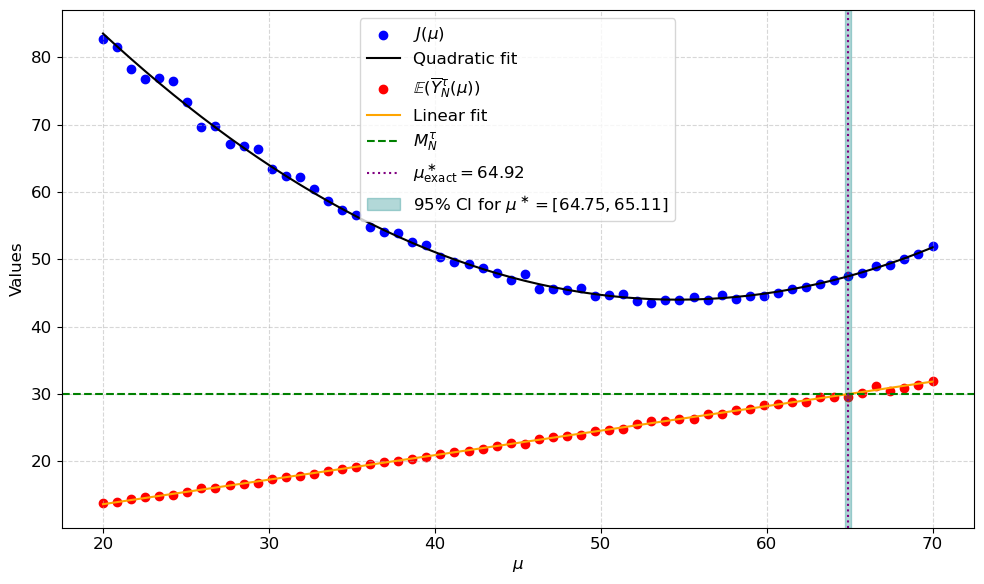

In [24]:
# ============================================================
# Plot mu vs J(mu), Linear and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot3, color ='Blue', label=r'$J(\mu)$')
plt.plot(mu_values, Y_fit_quad.mean(axis=0), color ='black', label=r'Quadratic fit')
plt.scatter(mu_values, EY_boot3, color ='red', label=r'$\mathbb{E}(\overline{Y}_N^\tau(\mu))$')
plt.plot(mu_values, Y_fit_lin.mean(axis=0), color ='orange', label=r'Linear fit')
plt.axhline(Y_demand, color='green', linestyle='--', label=r'$M_N^\tau$')
plt.axvline(mu_star3, color='purple', linestyle=':', label=fr'$\mu^\ast_{{\rm exact}} = {mu_star3:.2f}$', alpha=1)


CI3 = np.quantile(mu_star_samples3, [0.025, 0.975])        # 95% CI
plt.axvspan(CI3[0], CI3[1], color='Teal', alpha=0.3, label=fr'$95\%$ CI for $\mu^\ast = [{CI3[0]:.2f}, {CI3[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
# plt.title(r'')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

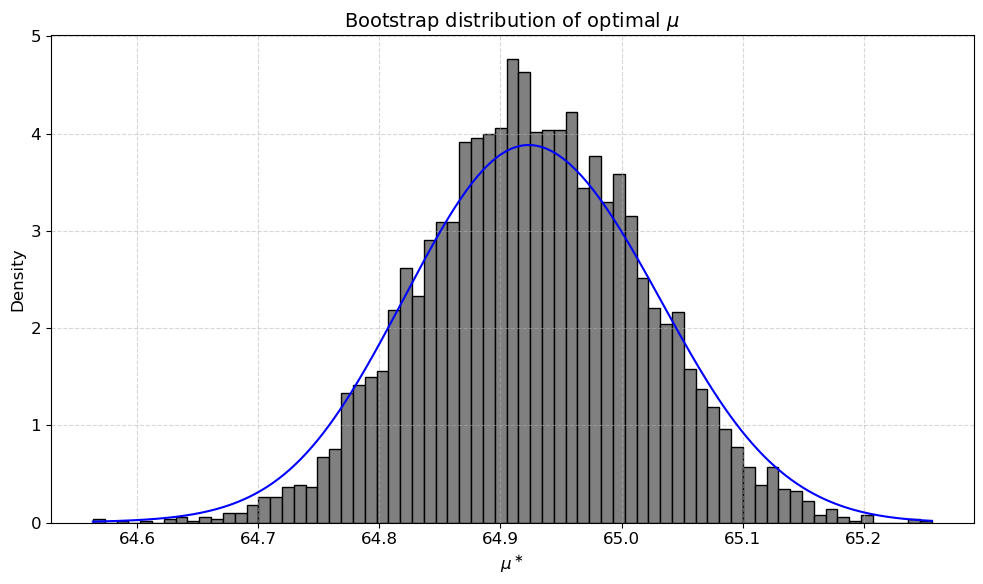

In [25]:
n = len(mu_star_samples3)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples3, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples3, bw_method=0.5)
x = np.linspace(min(mu_star_samples3), max(mu_star_samples3), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# The plot for the cost function with quadratic fit & $\mathbb{E}\left(Y(T)\right)$ with lineear fit and distribution for the optimal mu

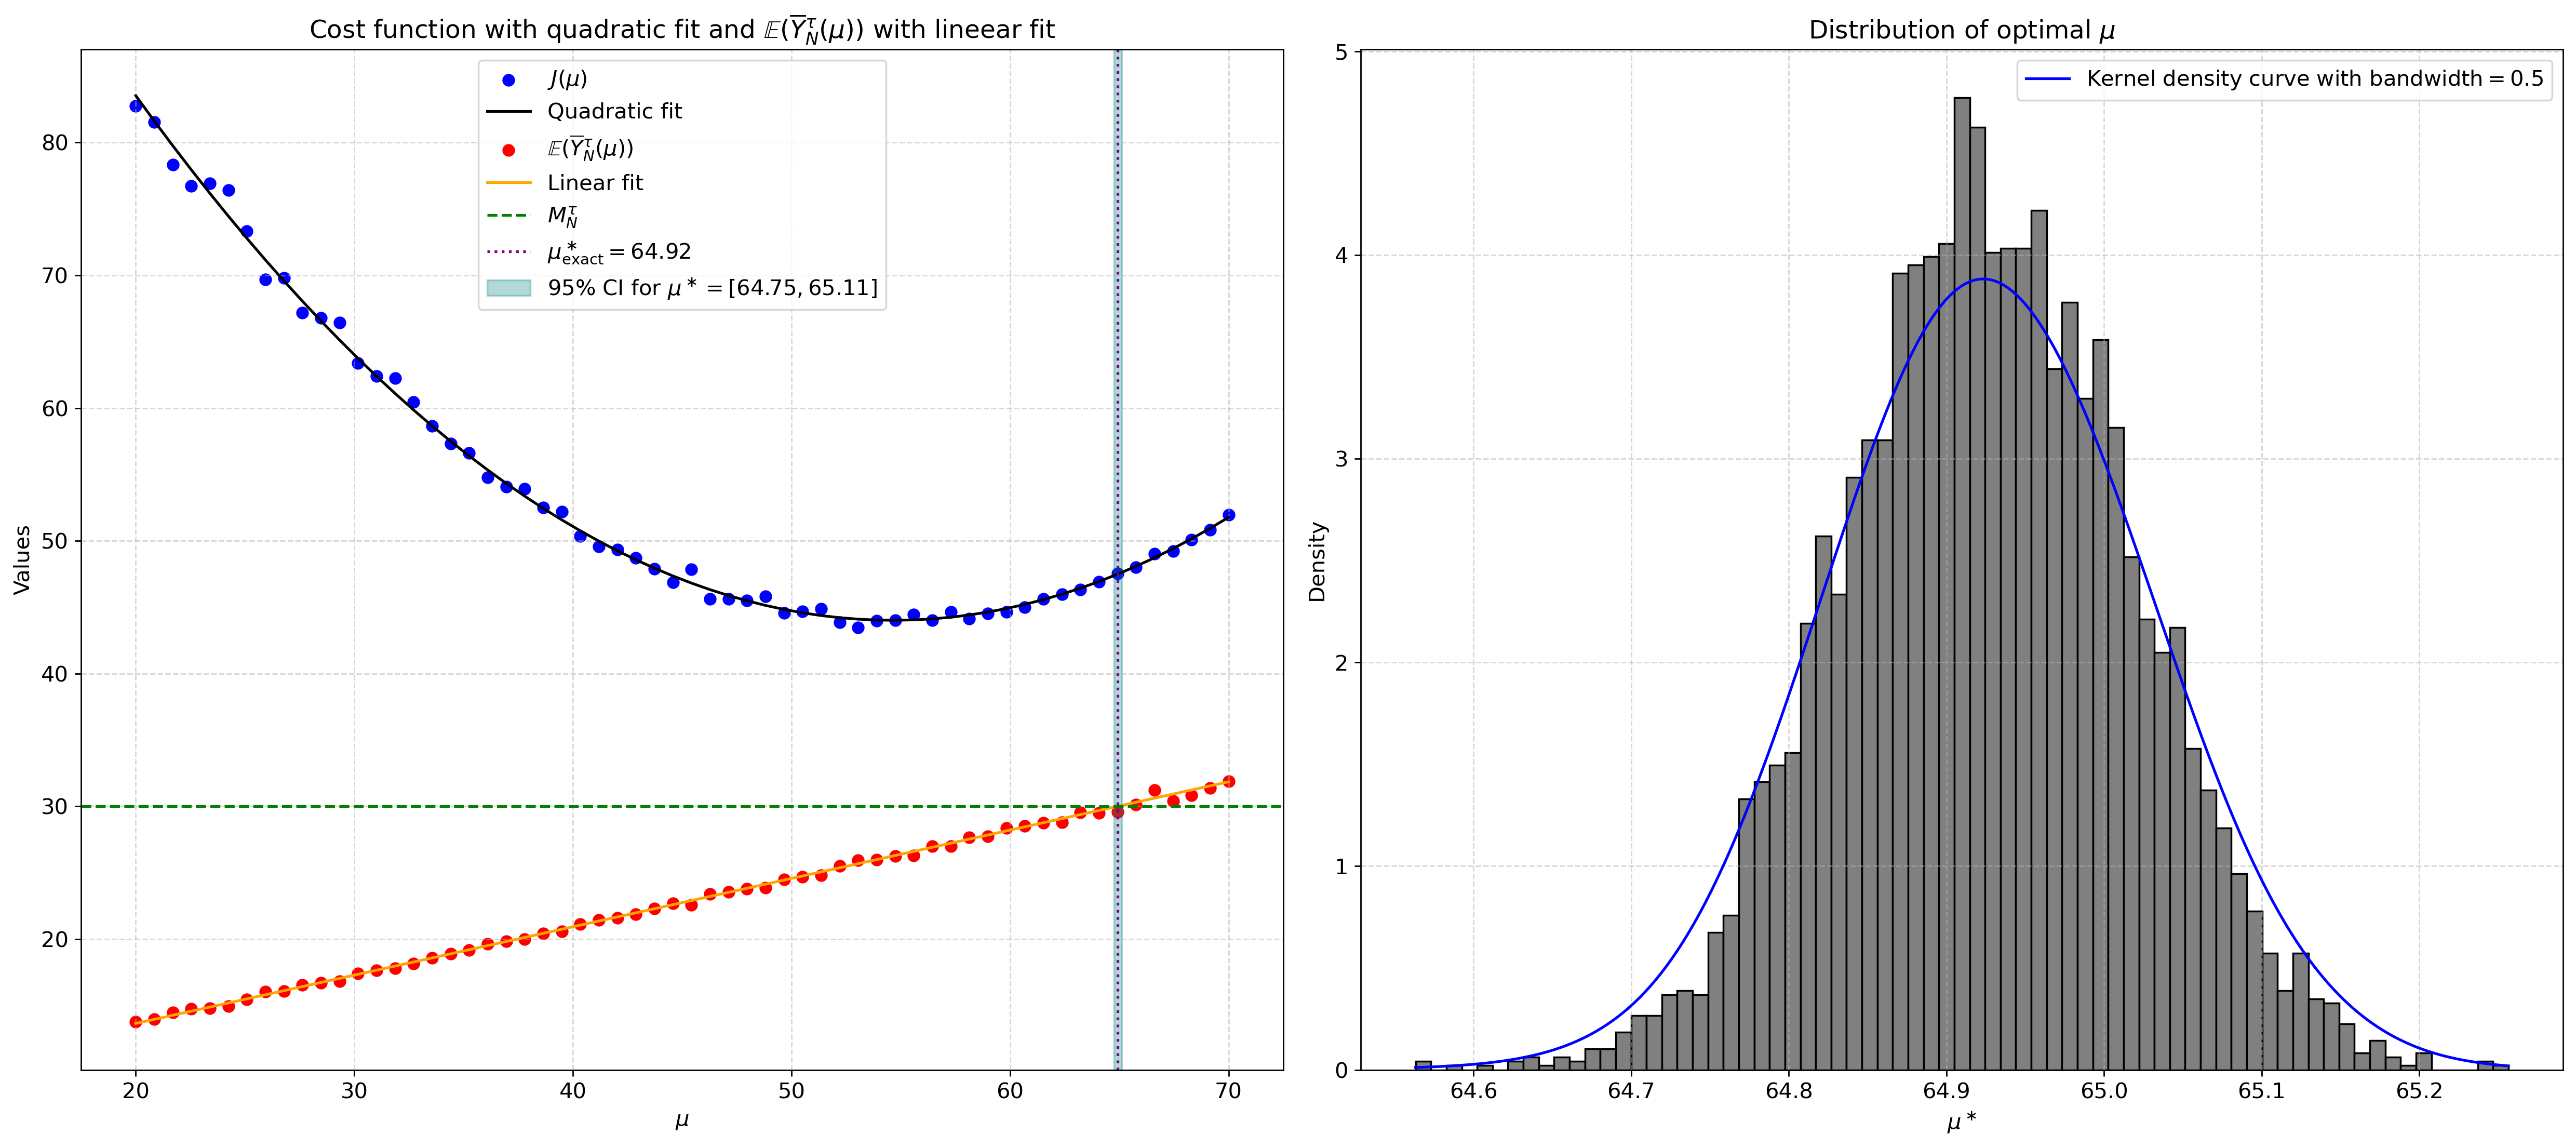

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, J_mu_boot3, color ='Blue', label=r'$J(\mu)$')
ax.plot(mu_values, Y_fit_quad.mean(axis=0), color ='black', label=r'Quadratic fit')

ax.scatter(mu_values, EY_boot3, color ='red', label=r'$\mathbb{E}(\overline{Y}_N^\tau(\mu))$')
ax.plot(mu_values, Y_fit_lin.mean(axis=0), color ='orange', label=r'Linear fit')


ax.axhline(Y_demand, color='green', linestyle='--', label=r'$M_N^\tau$')
ax.axvline(mu_star3, color='purple', linestyle=':', label=fr'$\mu^\ast_{{\rm exact}} = {mu_star3:.2f}$', alpha=1)


CI3 = np.quantile(mu_star_samples3, [0.025, 0.975])        # 95% CI
ax.axvspan(CI3[0], CI3[1], color='Teal', alpha=0.3, label=fr'$95\%$ CI for $\mu^\ast = [{CI3[0]:.2f}, {CI3[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title(r"Cost function with quadratic fit and $\mathbb{E}(\overline{Y}_N^\tau(\mu))$ with lineear fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples3)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples3, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples3, bw_method=0.5)
x = np.linspace(min(mu_star_samples3), max(mu_star_samples3), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(fr"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()

plt.savefig("Optimise_mu4_Tau_leap.png", format='png', bbox_inches='tight')
plt.show()